In [33]:
import os
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [34]:
hdf5_path = '/home/soochul/GoPro_hdf5/'
num_episodes = 205
episode_id = np.random.choice(num_episodes)
print(episode_id)
dataset_path = os.path.join(hdf5_path, f'ep_{episode_id}.hdf5')

171


In [35]:
with h5py.File(dataset_path, 'r') as root:
    is_sim = root.attrs['sim']
    original_action_shape = root['/action'].shape
    episode_len = original_action_shape[0]
    print(root['/action'][:].shape) # ndarray # max_ep_length, action dim (1885, 10)
    
    for key in root['/observations'].keys():
        # ['eef_pos', 'eef_rot', 'eef_rot_start', 'force', 'gripper_width', 'images', 'torque']
        print(key)
        if key == 'images':
            # images is a Group -> cam_name -> [:] -> ndarray
            print(root[f'/observations/{key}/top'][:].shape)
            # images: max_ep_length, channel, H, W
        else:
            # others are Dataset -> [:] -> ndarray
            print(root[f'/observations/{key}'][:].shape)
            # pos : max_ep_length, 3
            # rot : max_ep_length, 6
            # rot_start : max_ep_length, 6
            # force : max_ep_length, 3
            # torque: max_ep_length, 3
            # gripper_width : max_ep_length, 1


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/soochul/GoPro_hdf5/ep_171.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [36]:
episode_id = 10
dataset_path = os.path.join(hdf5_path, f'ep_{episode_id}.hdf5')
pos = None
width = None
images = None
with h5py.File(dataset_path, 'r') as root:
    pos = root['/observations/eef_pos'][:]
    width = root['/observations/gripper_width'][:]
    images = root[f'/observations/images/top'][:]

pos

array([[ 0.0279838 ,  0.01467424, -0.03999033],
       [ 0.02810134,  0.0149199 , -0.03996338],
       [ 0.02825999,  0.01500304, -0.03998135],
       ...,
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]], dtype=float32)

In [37]:
images[0]

array([[[8, 7, 7, ..., 8, 7, 6],
        [9, 8, 8, ..., 6, 6, 6],
        [9, 8, 8, ..., 8, 8, 7],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[5, 4, 4, ..., 5, 5, 4],
        [5, 4, 4, ..., 4, 4, 4],
        [5, 4, 4, ..., 6, 5, 5],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[7, 5, 6, ..., 5, 4, 3],
        [7, 5, 5, ..., 4, 4, 3],
        [7, 6, 6, ..., 5, 5, 4],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

In [38]:
episode_id1 = 1
dataset_path1 = os.path.join(hdf5_path, f'ep_{episode_id1}.hdf5')
pos1 = None
width1 = None
images1 = None
with h5py.File(dataset_path1, 'r') as root:
    pos1 = root['/observations/eef_pos'][:]
    width1 = root['/observations/gripper_width'][:]
    images1 = root[f'/observations/images/top'][:]

pos1

array([[-0.01419941, -0.11462712, -0.12009618],
       [-0.01481684, -0.11599703, -0.12192413],
       [-0.01463098, -0.11624518, -0.12198893],
       ...,
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]], dtype=float32)

In [39]:
pos - pos1

array([[0.04218321, 0.12930137, 0.08010585],
       [0.04291818, 0.13091692, 0.08196075],
       [0.04289097, 0.13124822, 0.08200757],
       ...,
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ]], dtype=float32)

In [40]:
def plot_traj(pos):
    # Extract relevant data
    x = pos[: , 0]
    y = pos[: , 1]
    z = pos[: , 2]

    ep_length = pos.shape[0]
    timestamps = np.array(range(ep_length))
    color_intensity_time = timestamps / timestamps[-1]
    
    # Create the 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=color_intensity_time, cmap='cool', s=1)
    
    # Label axes
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    # Add color bar for reference
    
    plt.show()

def plot_width(width):
    ep_length = width.shape[0]
    timestamps = np.array(range(ep_length))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    x = timestamps
    y = width
    ax.plot(x, y)
    plt.show()



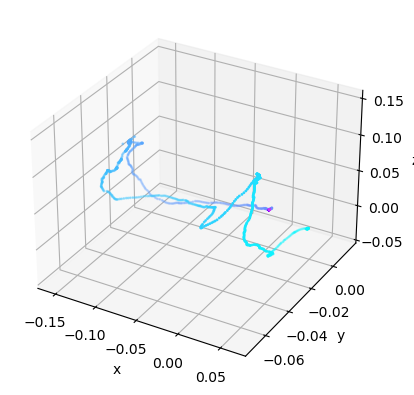

In [41]:
plot_traj(pos)

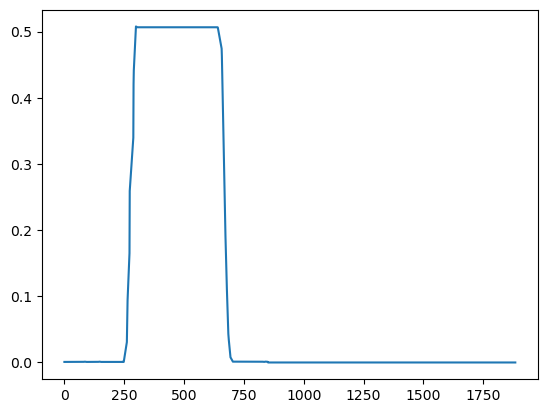

In [42]:
plot_width(width)

(3, 224, 224)
(3, 224, 224)
255
0


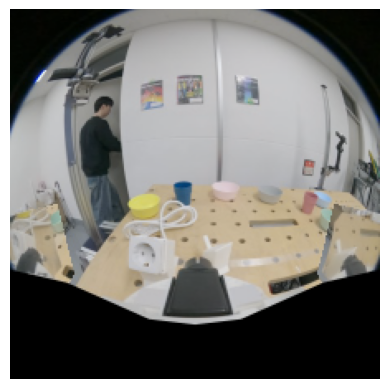

In [ ]:
image = images1[800]
print(image.shape)
image1 = np.moveaxis(image, 0, -1)
print(image.shape)
print(image1.max())
print(image1.min())
plt.imshow(image1)
plt.axis("off") 
plt.show()